# Step 011.3A — Vision Core Experimental Suite

This executed notebook presents train/validation-only evidence for VIS-001, VIS-004, VIS-005, and VIS-008. It uses deterministic local fixed-convolutional representations and does not download pretrained weights, inspect the locked test split, or alter the production final model.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display
ROOT = Path.cwd()
VISION = ROOT / "reports" / "course_coverage" / "vision"
profile = json.loads((VISION / "image_profile.json").read_text(encoding="utf-8-sig"))
profile


{'step': '011.3A',
 'status': 'PASS',
 'unique_image_count': 80,
 'train_unique_image_count': 60,
 'validation_unique_image_count': 20,
 'category_count': 10,
 'family_count': 5,
 'source_counts': {'generated_development': 40,
  'wikimedia_commons_open_license': 40},
 'category_counts': {'air_filter': 8,
  'alternator': 8,
  'brake_disc': 8,
  'brake_pad': 8,
  'coil_spring': 8,
  'headlight': 8,
  'oil_filter': 8,
  'shock_absorber': 8,
  'starter': 8,
  'taillight': 8},
 'width': {'min': 224, 'median': 269.5, 'max': 1280},
 'height': {'min': 224, 'median': 264.0, 'max': 1707},
 'brightness': {'min': 0.2394285351037979,
  'mean': 0.6587970403954386,
  'max': 0.9227691292762756},
 'contrast': {'min': 0.1041012778878212,
  'mean': 0.233231761213392,
  'max': 0.3324827551841736},
 'exact_duplicate_groups': 0,
 'review_required_count': 9,
 'locked_test_csv_files_opened': False,
 'test_split_used': False,
 'final_test_evaluation_authorized': False,
 'production_final_model_changed': False,

## VIS-001 — Image inventory and review flags


In [2]:
inventory = pd.read_csv(VISION / "image_inventory.csv")
review = pd.read_csv(VISION / "annotation_review.csv")
display(inventory.head(10))
display(review[review["review_required"] == True].head(10))


,split,image_id,part_group_id,image_path,part_family,part_category,source,width,height,aspect_ratio,megapixels,brightness,contrast,edge_density,sha256,exact_duplicate_count
0,train,air_filter_001_01,air_filter_001,data/development/images/air_filter_001_01.png,filtration,air_filter,generated_development,224,224,1.0,0.050176,0.830523,0.223420,0.022288,876958c51015a894a09b66f1d18e4853447e47f28e58af...,1
1,train,air_filter_002_01,air_filter_002,data/development/images/air_filter_002_01.png,filtration,air_filter,generated_development,224,224,1.0,0.050176,0.830523,0.223420,0.022288,76a0e3675fb1235d6f5573d6200599438300caaf8bbbf4...,1
2,train,air_filter_003_01,air_filter_003,data/development/images/air_filter_003_01.png,filtration,air_filter,generated_development,224,224,1.0,0.050176,0.830523,0.223420,0.022288,588395f21412097d86a3c1eb157513aa77a5a4440a5323...,1
3,train,alternator_001_01,alternator_001,data/development/images/alternator_001_01.png,electrical,alternator,generated_development,224,224,1.0,0.050176,0.818215,0.267307,0.013048,9bd57bfcea1571fb294bbe1181b7d021a1db01e2e99a67...,1
4,train,alternator_002_01,alternator_002,data/development/images/alternator_002_01.png,electrical,alternator,generated_development,224,224,1.0,0.050176,0.818215,0.267307,0.013048,a764b95dd9e7e6d52142533596c65a82b08bc986aac005...,1
5,train,alternator_003_01,alternator_003,data/development/images/alternator_003_01.png,electrical,alternator,generated_development,224,224,1.0,0.050176,0.818215,0.267307,0.013048,99d91936473980711e052f33d79783cfecd0f1e9ddd22c...,1
6,train,brake_disc_001_01,brake_disc_001,data/development/images/brake_disc_001_01.png,braking,brake_disc,generated_development,224,224,1.0,0.050176,0.858639,0.211303,0.017214,943915614fc73c1a88687551039eb88fbe214c2268d7e4...,1
7,train,brake_disc_002_01,brake_disc_002,data/development/images/brake_disc_002_01.png,braking,brake_disc,generated_development,224,224,1.0,0.050176,0.858639,0.211303,0.017214,778be1e1a07e565fa2765622153f2eae0e684d76d77f9f...,1
8,train,brake_disc_003_01,brake_disc_003,data/development/images/brake_disc_003_01.png,braking,brake_disc,generated_development,224,224,1.0,0.050176,0.858639,0.211303,0.017214,80d51330c20ea36686d369adb8ede26600a66305bbc121...,1
9,train,brake_pad_001_01,brake_pad_001,data/development/images/brake_pad_001_01.png,braking,brake_pad,generated_development,224,224,1.0,0.050176,0.818362,0.261333,0.011982,8d591bb8050017d5a7bcb281590a5e301a1bd8d7661101...,1


,split,image_id,part_group_id,image_path,part_family,part_category,source,width,height,aspect_ratio,...,edge_density,sha256,exact_duplicate_count,low_brightness_flag,high_brightness_flag,low_contrast_flag,extreme_aspect_ratio_flag,exact_duplicate_flag,review_required,review_reasons
12,train,coil_spring_001_01,coil_spring_001,data/development/images/coil_spring_001_01.png,suspension,coil_spring,generated_development,224,224,1.000000,...,0.011473,9bda6d1eead9b927aa309dd1f78fe6e47fe51429be493d...,1,False,True,False,False,False,True,high_brightness
13,train,coil_spring_002_01,coil_spring_002,data/development/images/coil_spring_002_01.png,suspension,coil_spring,generated_development,224,224,1.000000,...,0.011473,e736891836e2e064bb0772ee37ff7b0969f39f5d23e41d...,1,False,True,False,False,False,True,high_brightness
14,train,coil_spring_003_01,coil_spring_003,data/development/images/coil_spring_003_01.png,suspension,coil_spring,generated_development,224,224,1.000000,...,0.011473,387a0e286619f507cbcc4e56e70354074b97b2dafa7721...,1,False,True,False,False,False,True,high_brightness
45,train,headlight_001_01,headlight_001,data/development/images/headlight_001_01.png,lighting,headlight,generated_development,224,224,1.000000,...,0.012022,67df37389449933ab3466c232cead0b1f6920190dd714c...,1,False,True,False,False,False,True,high_brightness
46,train,headlight_002_01,headlight_002,data/development/images/headlight_002_01.png,lighting,headlight,generated_development,224,224,1.000000,...,0.012022,bb8204c3b29ef9bf4e2e6842298ce51bcfd4fd73aae731...,1,False,True,False,False,False,True,high_brightness
47,train,headlight_003_01,headlight_003,data/development/images/headlight_003_01.png,lighting,headlight,generated_development,224,224,1.000000,...,0.012022,791192c6f30ced2b89c12f0248c2553cf4dac7136b8ec1...,1,False,True,False,False,False,True,high_brightness
64,validation,coil_spring_004_01,coil_spring_004,data/development/images/coil_spring_004_01.png,suspension,coil_spring,generated_development,224,224,1.000000,...,0.011473,0d4016a4cfbc92883592106c3fed7adaf9a3af46b64e3b...,1,False,True,False,False,False,True,high_brightness
73,validation,external_image_starter_1650046,external_group_starter_1650046,data/external/open_license/images/starter/comm...,electrical,starter,wikimedia_commons_open_license,943,324,2.910494,...,0.029341,cabf7de58999ba7bd77964764a20fc39093ec5cfbb98fd...,1,False,False,False,True,False,True,extreme_aspect_ratio
75,validation,headlight_004_01,headlight_004,data/development/images/headlight_004_01.png,lighting,headlight,generated_development,224,224,1.000000,...,0.012022,bf21ea23646d5bd323c397fbfd078a711064069e01fb2b...,1,False,True,False,False,False,True,high_brightness


## VIS-004 — Representation and resolution comparison


In [3]:
representation = pd.read_csv(VISION / "representation_resolution_comparison.csv")
display(representation.sort_values(["validation_macro_f1_mean", "validation_accuracy_mean"], ascending=False))


,representation,resolution,run_count,validation_macro_f1_mean,validation_macro_f1_std,validation_accuracy_mean,validation_accuracy_std,feature_dimension,parameter_count,training_time_seconds_mean,inference_time_ms_mean,selected_configuration
0,global_pool,64,3,0.660000,0.0,0.65,0.0,240,2410,0.017538,0.023600,True
1,global_pool,48,3,0.657143,0.0,0.65,0.0,240,2410,0.016579,0.023495,False
2,global_pool,32,3,0.650000,0.0,0.65,0.0,240,2410,0.022287,0.025053,False
3,intermediate_fixed_conv,32,3,0.576667,0.0,0.60,0.0,368,3690,0.009943,0.024600,False
4,intermediate_fixed_conv,64,3,0.553333,0.0,0.55,0.0,368,3690,0.009467,0.023965,False
5,multi_stage_fixed_conv,48,3,0.546667,0.0,0.55,0.0,416,4170,0.012779,0.030833,False
6,intermediate_fixed_conv,48,3,0.543333,0.0,0.55,0.0,368,3690,0.011537,0.024143,False
7,multi_stage_fixed_conv,32,3,0.543333,0.0,0.55,0.0,416,4170,0.012423,0.029828,False
8,multi_stage_fixed_conv,64,3,0.543333,0.0,0.55,0.0,416,4170,0.010902,0.024607,False


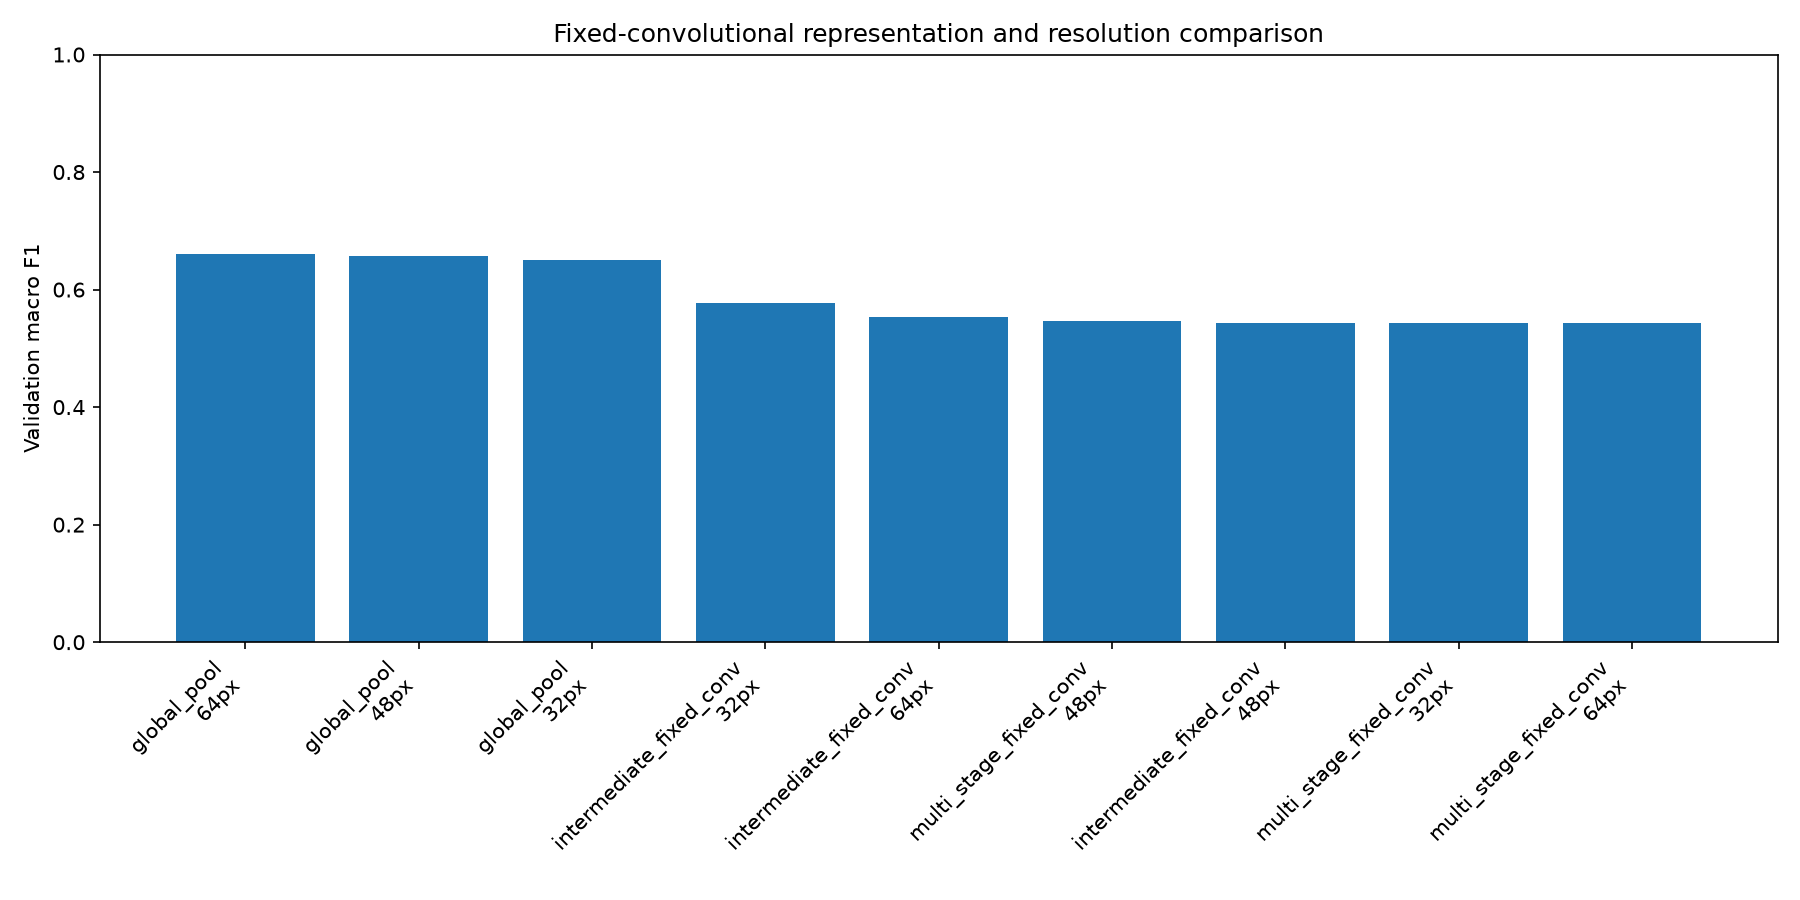

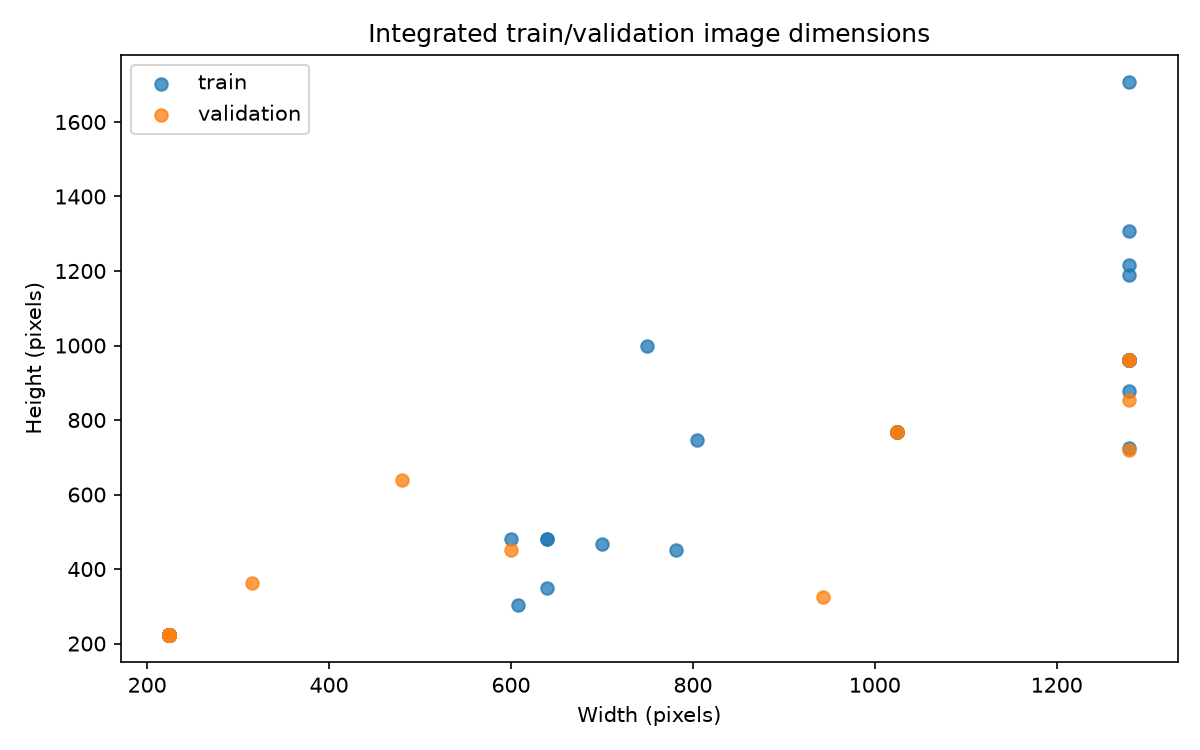

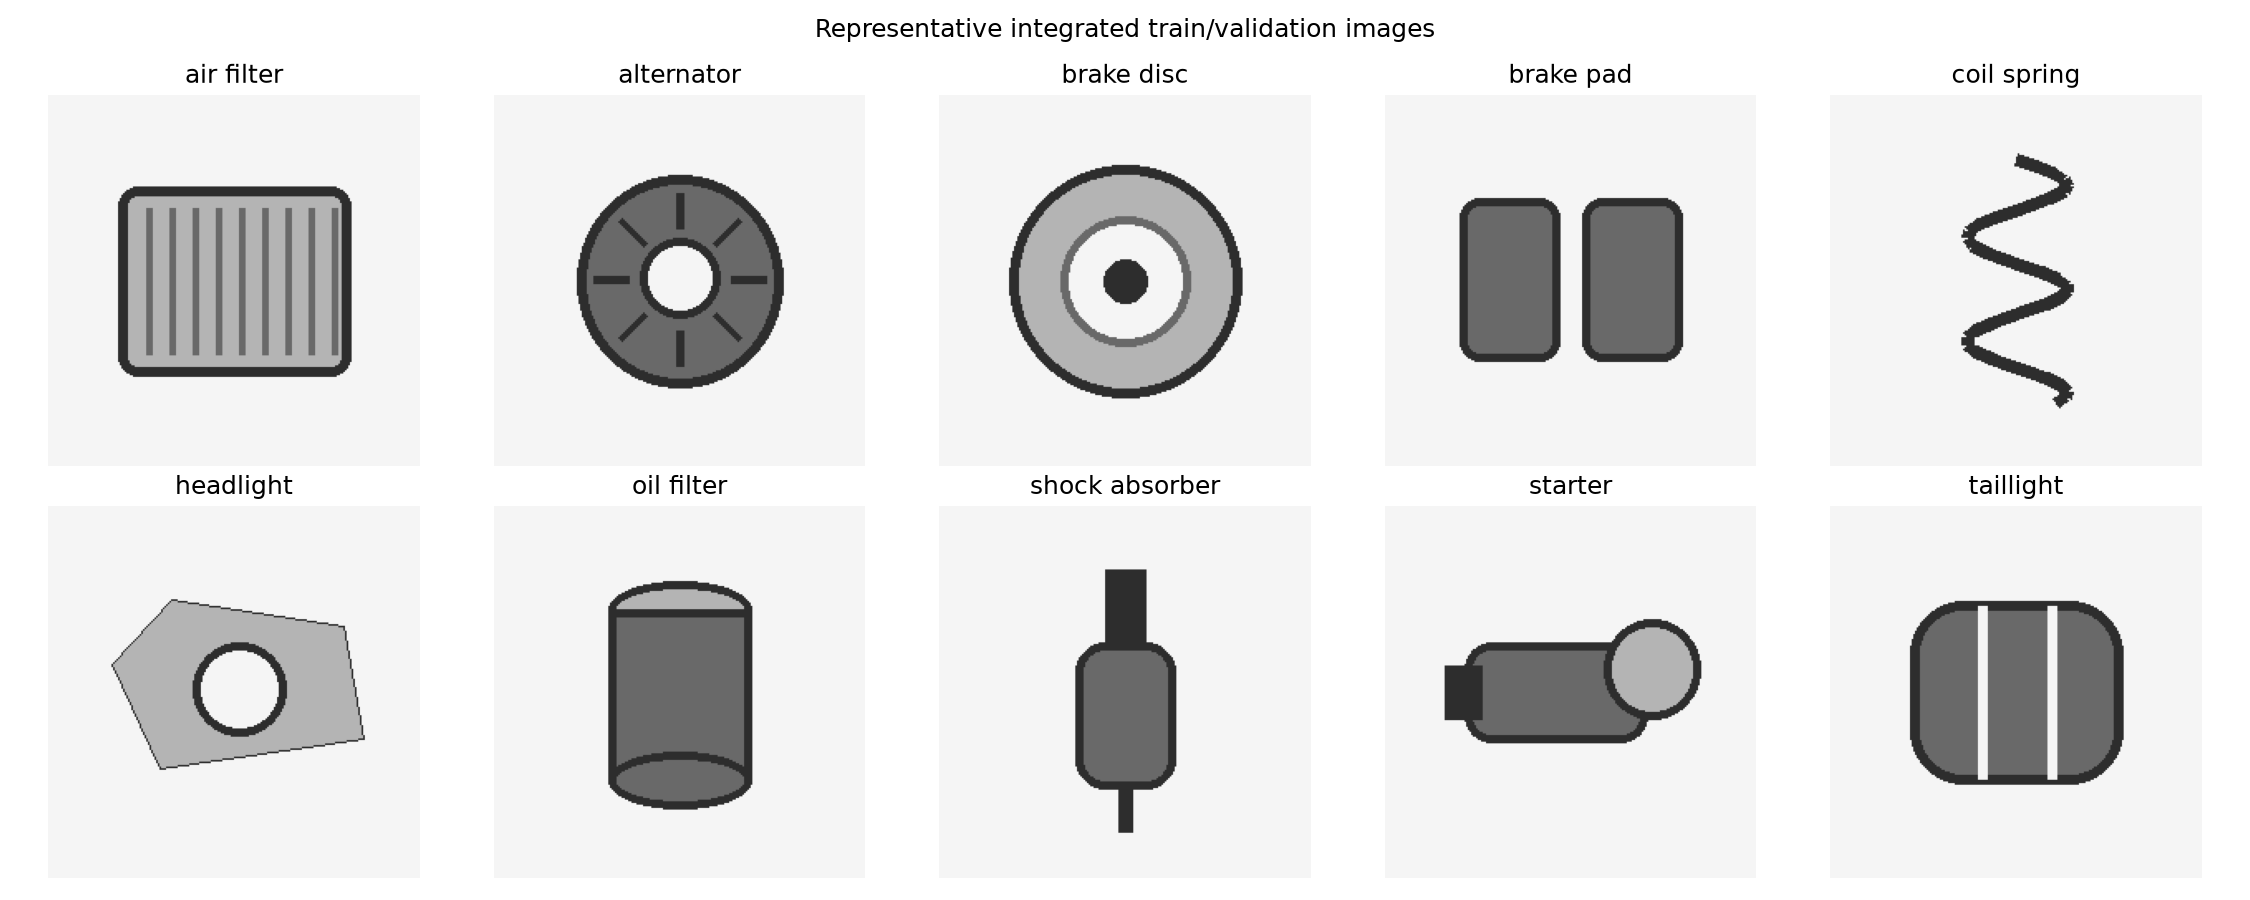

In [4]:
from PIL import Image
for name in ["representation_macro_f1.png", "image_dimension_scatter.png", "representative_image_gallery.png"]:
    display(Image.open(VISION / "figures" / name))


## VIS-008 — Failure-driven augmentation ablation


In [5]:
augmentation = pd.read_csv(VISION / "augmentation_comparison.csv")
failure_matrix = pd.read_csv(VISION / "failure_to_augmentation_matrix.csv")
display(augmentation.sort_values(["validation_macro_f1_mean", "validation_accuracy_mean"], ascending=False))
display(failure_matrix)


,augmentation_policy,run_count,validation_macro_f1_mean,validation_macro_f1_std,validation_accuracy_mean,validation_accuracy_std,feature_dimension,parameter_count,training_time_seconds_mean,inference_time_ms_mean,selected_configuration,macro_f1_delta_vs_none
0,combined,3,0.710000,0.028868,0.716667,0.028868,240,2410,0.023468,0.024752,True,0.050000
1,brightness,3,0.683492,0.025760,0.683333,0.028868,240,2410,0.024700,0.024372,False,0.023492
2,center_crop,3,0.682222,0.028350,0.683333,0.028868,240,2410,0.023766,0.027253,False,0.022222
3,jpeg_compression,3,0.660476,0.000000,0.650000,0.000000,240,2410,0.022776,0.026390,False,0.000476
4,none,3,0.660000,0.000000,0.650000,0.000000,240,2410,0.018377,0.024945,False,0.000000


,part_category,validation_accuracy,mean_confidence,observed_failure,justified_augmentation,label_validity,rationale
0,air_filter,1.0,0.768687,no_validation_error_observed,jpeg_compression,preserved under moderate transform,Stress-test robustness to realistic image comp...
1,alternator,1.0,0.832284,no_validation_error_observed,jpeg_compression,preserved under moderate transform,Stress-test robustness to realistic image comp...
2,brake_disc,0.5,0.665524,category_confusion,center_crop,preserved under moderate transform,Test whether tighter object framing reduces ba...
3,brake_pad,1.0,0.782475,no_validation_error_observed,jpeg_compression,preserved under moderate transform,Stress-test robustness to realistic image comp...
4,coil_spring,0.5,0.593424,category_confusion,center_crop,preserved under moderate transform,Test whether tighter object framing reduces ba...
5,headlight,0.5,0.769585,category_confusion,center_crop,preserved under moderate transform,Test whether tighter object framing reduces ba...
6,oil_filter,0.5,0.646176,category_confusion,center_crop,preserved under moderate transform,Test whether tighter object framing reduces ba...
7,shock_absorber,1.0,0.626878,low_confidence,brightness,preserved under moderate transform,Test moderate exposure variation for low-confi...
8,starter,1.0,0.803486,no_validation_error_observed,jpeg_compression,preserved under moderate transform,Stress-test robustness to realistic image comp...
9,taillight,0.5,0.839762,category_confusion,center_crop,preserved under moderate transform,Test whether tighter object framing reduces ba...


## VIS-005 — Model-independent occlusion evidence


In [6]:
explainability = json.loads((VISION / "explainability_summary.json").read_text(encoding="utf-8-sig"))
regions = pd.read_csv(VISION / "region_perturbation_summary.csv")
explainability, display(regions.head(12))


,example_index,image_id,part_category,baseline_true_probability,center_mask_probability,border_mask_probability,center_prediction_delta,border_prediction_delta,max_occlusion_grid_row,max_occlusion_grid_column,foreground_proxy_grid_row,foreground_proxy_grid_column,automated_proxy_aligned
0,1,external_image_coil_spring_4525127,coil_spring,0.031829,0.059311,7.058863e-03,-0.027482,0.024770,0,1,1,1,True
1,2,external_image_taillight_4518332,taillight,0.014582,0.049570,9.544227e-01,-0.034988,-0.939841,1,1,0,1,True
2,3,external_image_oil_filter_1715177,oil_filter,0.003470,0.000682,5.251540e-07,0.002788,0.003470,0,2,2,2,False
3,4,external_image_headlight_2983638,headlight,0.001790,0.001160,1.073780e-04,0.000630,0.001683,1,1,1,0,True
4,5,external_image_shock_absorber_551757,shock_absorber,0.274162,0.014728,5.566391e-04,0.259434,0.273605,1,1,2,1,True
5,6,air_filter_004_01,air_filter,0.538518,0.177835,5.025927e-02,0.360684,0.488259,2,1,1,2,False
6,7,external_image_brake_pad_2470132,brake_pad,0.610532,0.220181,9.656490e-02,0.390351,0.513967,1,1,2,1,True
7,8,external_image_starter_1650046,starter,0.668617,0.007350,5.687689e-05,0.661268,0.668560,1,2,1,1,True


({'step': '011.3A',
  'status': 'PASS',
  'method': 'model_independent_3x3_occlusion_and_crop_retest',
  'selected_example_count': 8,
  'occlusion_evaluation_count': 72,
  'manual_plausible_region_review_rate': None,
  'manual_review_claimed': False,
  'automated_foreground_proxy_definition': 'highest local gradient-energy patch',
  'automated_foreground_proxy_alignment_rate': 0.75,
  'corner_maximum_count': 1,
  'mean_center_prediction_delta': 0.20158544863079442,
  'mean_border_prediction_delta': 0.12930929410948266,
  'failure_case_count': 7,
  'human_interpretation_boundary': 'No human plausible-region score is claimed. The automated proxy is diagnostic only.',
  'locked_test_csv_files_opened': False,
  'test_split_used': False,
  'final_test_evaluation_authorized': False,
  'production_final_model_changed': False,
  'pretrained_weights_downloaded': False,
  'synthetic_human_agreement_reported': False},
 None)

### Interpretation boundary

The occlusion analysis reports an automated foreground-proxy alignment measure. It does **not** claim a human plausible-region review rate. Human agreement remains deferred to VIS-007 until genuine independent annotations are available.
